In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures ,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [4]:
X = 6*np.random.rand(200,1)-3  #generates 200 random numbers between 0 and 1 -> multiply 6 -> subtracting 3 shifts the range: X contains 200 random values between -3 and 3

In [5]:
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1) #np.random.randn(200, 1): This generates random noise from a standard normal distribution.

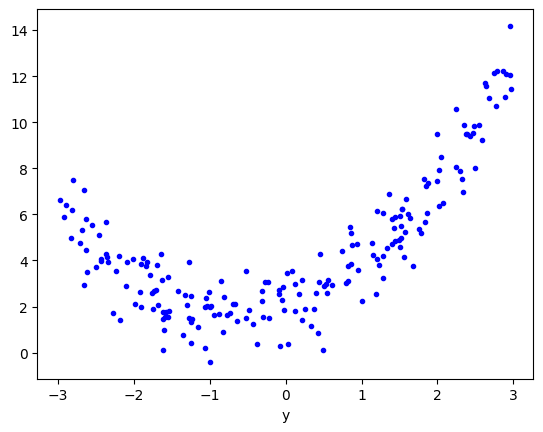

In [7]:
plt.plot(X,y,'b.')
plt.xlabel("X")
plt.xlabel("y")
plt.show()

In [9]:
# Train test split
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=2)

In [10]:
lr = LinearRegression()

In [11]:
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import r2_score

y_pred = lr.predict(X_test)  # y predict wil be always on Xtest data

score = r2_score(y_test, y_pred)
print(score)

In [ ]:
plt.plot(X_train, lr.predict(X_train), color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [25]:
# Import PolynomialFeatures to convert normal features into polynomial features
from sklearn.preprocessing import PolynomialFeatures

# Create a PolynomialFeatures object with degree = 2
# This will convert X into [1, X, X²]
poly = PolynomialFeatures(degree=2)

# Learn the polynomial transformation from X_train
# and transform X_train from [X] into [1, X, X²]
X_train_trans = poly.fit_transform(X_train)

# Transform X_test using the SAME polynomial transformation
# We use only transform() because poly was already fitted on X_train
X_test_trans = poly.transform(X_test)


0.9162365254393795


In [26]:

# Print the first original training value
# Example: [2.55693386]
print(X_train[0])

# Print the same value after polynomial transformation
# Example: [1, 2.55693386, 6.53791074]
# Here:
# 1            -> bias/intercept feature (X⁰)
# 2.55693386   -> original feature (X¹)
# 6.53791074   -> squared feature (X²)
print(X_train_trans[0])


[-2.27360294]
[ 1.         -2.27360294  5.16927032]


In [28]:

# Create a Linear Regression model
# Although it is called LinearRegression, it can fit a polynomial curve
# because we are giving it polynomial features [1, X, X²]
lr = LinearRegression()

# Train the Linear Regression model using polynomial training features
lr.fit(X_train_trans,y_train)



LinearRegression()

In [29]:
# Predict y values using polynomial test features
y_pred=lr.predict(X_test_trans)
# Calculate the R² score to check model performance
score = r2_score(y_test, y_pred)

# Print the R² score
print(score)

0.9162365254393795


In [33]:
print(lr.coef_)
print(lr.intercept_)

[[0.         1.00946053 0.80140915]]
[2.04560873]


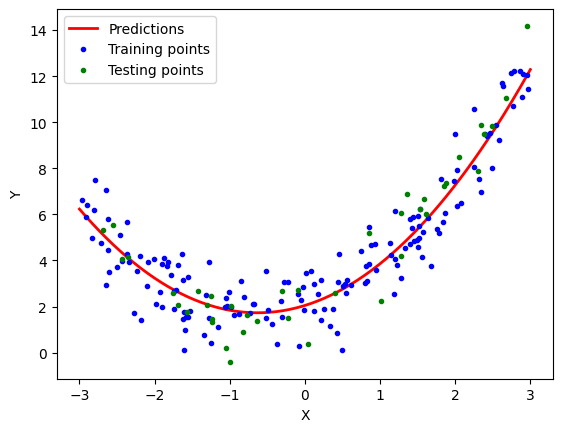

In [34]:
# Create 200 evenly spaced X values between -3 and 3
# reshape(200, 1) converts the array into the 2D shape required by sklearn
X_new = np.linspace(-3, 3, 200).reshape(200, 1)

# Convert the new X values into polynomial features
# If degree=2, it transforms X into [1, X, X²]
X_new_poly = poly.transform(X_new)

# Use the trained Linear Regression model to predict y values
# based on the polynomial features
y_new = lr.predict(X_new_poly)


# Plot the predicted polynomial regression curve
# X_new contains smooth, ordered values from -3 to 3
# y_new contains the corresponding predicted values
# "r-" means red solid line
# linewidth=2 sets the thickness of the line
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")

# Plot the training data as blue dots
# "b." means blue dots
plt.plot(X_train, y_train, "b.", label="Training points")

# Plot the testing data as green dots
# "g." means green dots
plt.plot(X_test, y_test, "g.", label="Testing points")

# Give the X-axis a label
plt.xlabel("X")

# Give the Y-axis a label
plt.ylabel("Y")

# Display the legend: Predictions, Training points, Testing points
plt.legend()

# Display the final graph
plt.show()

Original X
    ↓
PolynomialFeatures(degree=55)
    ↓
X, X², X³, ... X⁵⁵
    ↓
StandardScaler()
    ↓
Scaled polynomial features
    ↓
LinearRegression()
    ↓
Prediction

In [ ]:
# Define a function that creates and plots polynomial regression
# The 'degree' parameter decides the degree of the polynomial
def polynomial_regression(degree):

    # Create 100 evenly spaced values between -3 and 3
    # reshape(100, 1) converts X_new into a 2D column array
    # These values are used to draw a smooth prediction curve
    X_new = np.linspace(-3, 3, 100).reshape(100, 1)

    # Create PolynomialFeatures for the given degree
    # Example:
    # degree=2  -> [X, X²]
    # degree=3  -> [X, X², X³]
    # include_bias=False means it will NOT add the constant column [1]
    polybig_features = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    # Create a StandardScaler object
    # This will standardize the polynomial features
    # so that features such as X, X², X³, ... are on comparable scales
    std_scaler = StandardScaler()

    # Create a Linear Regression model
    lin_reg = LinearRegression()

    # Create a Pipeline that performs all three steps automatically:
    # Step 1: Convert X into polynomial features
    # Step 2: Standardize those polynomial features
    # Step 3: Apply Linear Regression
    polynomial_regression = Pipeline([
        ("poly_features", polybig_features),
        ("std_scaler", std_scaler),
        ("lin_reg", lin_reg),
    ])

    # Train the entire pipeline using X and y
    # Internally:
    # X -> PolynomialFeatures -> StandardScaler -> LinearRegression
    polynomial_regression.fit(X, y)

    # Predict y values for the 100 X_new values
    # The pipeline automatically applies:
    # PolynomialFeatures -> StandardScaler -> LinearRegression prediction
    y_newbig = polynomial_regression.predict(X_new)

    # Plot the polynomial regression prediction as a red line
    # The label automatically shows the degree used
    plt.plot(
        X_new,
        y_newbig,
        "r-",
        label="Degree " + str(degree),
        linewidth=2
    )

    # Plot training data as blue dots
    plt.plot(X_train, y_train, "b.", linewidth=3)

    # Plot testing data as green dots
    plt.plot(X_test, y_test, "g.", linewidth=3)

    # Display the legend in the upper-left corner
    plt.legend(loc="upper left")

    # Label the X-axis
    plt.xlabel("X")

    # Label the Y-axis
    plt.ylabel("y")

    # Set the visible graph area
    # X-axis: -3 to 3
    # Y-axis: 0 to 10
    plt.axis([-3, 3, 0, 10])

    # Display the graph
    plt.show()



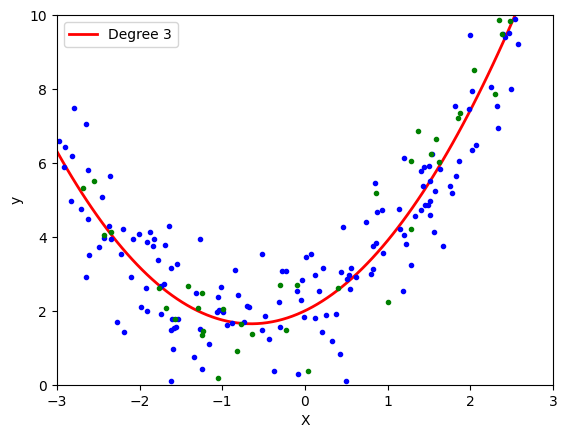

In [42]:

# Call the function with polynomial degree
polynomial_regression(3)

In [43]:
!git add .
!git commit -m "Add polynomial regression model"
!git push

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [ ]:
!git add .
!git commit -m "Add polynomial regression model"
!git push